In [ ]:
import os
from pathlib import Path
import h5py
import numpy as np
import pandas as pd
from tqdm import tqdm
from src.module.utils import load_config, load_npy
import matplotlib.pyplot as plt
from src.module.signal_quality_assessment import process_assess

In [ ]:
"""
Thoracic: 흉부, 폐, 복부 등의 수술
Cardiac: 심장
Gynecologic: 부인과
Obstetric: 산부인과

VitalDB는 Cardiac & Obstetric surgery는 애초에 배제하고 수집되었으며
MOVER는 ICD-10-PCS 코드 중 앞 두자리가 다음과 같은 경우를 제외하면 되겠다:
- Cardiac = '02*'
- Obstetric = '10*'

[최종] Cardiac & Gynecologic surgery 배제
VitalDB = Exclude cardiac, gynecologic
MOVER = Exclude cardiac('02'), gynecologic('10', '0U')
"""


def vitaldb_prepare_cohort(file_path) -> pd.DataFrame:
    cohort = pd.read_csv(file_path / "clinical_data.csv").reset_index(drop=True)
    cohort["age_num"] = np.where((cohort["age"] == ">89"), 90, cohort["age"]).astype(
        np.float32  # age < 1
    )
    cohort = (
        cohort.query("18 <= age_num")
        .drop_duplicates(["caseid"], keep=False)
        .query("department not in ['Gynecology']")
        # .query("department not in ['Thoracic surgery', 'Gynecology']")
        .query("ane_type == 'General'")
    )
    return cohort


def mover_prepare_cohort(file_path) -> pd.DataFrame:
    pat_info = pd.read_csv(file_path / "patient_information.csv")
    pat_code = pd.read_csv(file_path / "patient_coding.csv")
    pid_to_mrn = pd.read_csv(file_path / "EPIC_MRN_PAT_ID.csv")
    selected_mrn = pat_code[
        ~pat_code.REF_BILL_CODE.apply(lambda x: str(x)[:2] in ["02", "10", "0U"])
    ]["MRN"].unique()
    cohort = (
        pd.merge(pid_to_mrn, pat_info, how="inner", on=["LOG_ID", "MRN"])
        .drop_duplicates()
        .reset_index(drop=True)
    )
    cohort = (
        cohort.query("18 <= BIRTH_DATE")
        .query("PRIMARY_ANES_TYPE_NM == 'General'")
        .query("MRN.isin(@selected_mrn)")  # cardiac & obstetric surgery excluded
        .reset_index(drop=True)
    )
    return cohort


def load_h5(file_path) -> tuple:
    with h5py.File(file_path, "r") as f:
        ts = f["signal/ts"][:]
        sig = f["signal/abp"][:]
        mbp = f["signal/mbp"][:]
        sqi = f["signal/sqi"][:]
        fs = f["signal"].attrs["fs"]
        sig_len = f["signal"].attrs["len"]
        cid = f.attrs["caseid"].astype(str)

    return cid, fs, sig_len, ts, sig, mbp, sqi

In [3]:
data_dir = Path("../../data")
mover_cohort = mover_prepare_cohort(data_dir / "mover")

In [4]:
# 전처리된 데이터만 baseline characterisitcs를 추출한다.
mover_caselist = sorted(
    [x.parent.name for x in (data_dir / "mover" / "02.processed").rglob("*.h5")]
)
print(len(mover_caselist))

1388


In [5]:
mover_cohort = mover_cohort.query("PAT_ID.isin(@mover_caselist)").reset_index(drop=True)
print("MOVER case no: ", mover_cohort.LOG_ID.nunique())
print("MOVER patient no: ", mover_cohort.PAT_ID.nunique())

MOVER case no:  2364
MOVER patient no:  1316


In [10]:
config = load_config("../../config/conf.yaml")
src_path = Path(config["data_path"]).expanduser()
file_path = Path(config["data_path"]).expanduser() / "mover" / "02.processed"

In [7]:
mov_pos_cid = np.hstack(
    [
        load_npy(fp)
        for fp in (src_path / "mover" / "05.dataset_new").rglob(
            "hypophetversion2*pos_cid.npy"
        )
    ]
)
mov_neg_cid = np.hstack(
    [
        load_npy(fp)
        for fp in (src_path / "mover" / "05.dataset_new").rglob(
            "hypophetversion2*neg_cid.npy"
        )
    ]
)
mov_cid = np.hstack([mov_pos_cid, mov_neg_cid])
print(mov_pos_cid.shape, mov_neg_cid.shape, mov_cid.shape)

mov_pos_seg = np.hstack(
    [
        load_npy(fp)
        for fp in (src_path / "mover" / "05.dataset_new").rglob(
            "hypophetversion2*pos_segments.npy"
        )
    ]
)
mov_neg_seg = np.hstack(
    [
        load_npy(fp)
        for fp in (src_path / "mover" / "05.dataset_new").rglob(
            "hypophetversion2*neg_segments.npy"
        )
    ]
)
mov_seg = np.vstack([mov_pos_seg, mov_neg_seg])
print(mov_pos_seg.shape, mov_neg_seg.shape, mov_seg.shape)

(19192,) (165253,) (184445,)
(19192, 3000) (165253, 3000) (184445, 3000)


In [16]:
cid, fs, sig_len, ts, sig, mbp, sqi = load_h5(
    file_path / mov_cid[-2] / f"{mov_cid[-2]}_100fs_processed.h5"
)

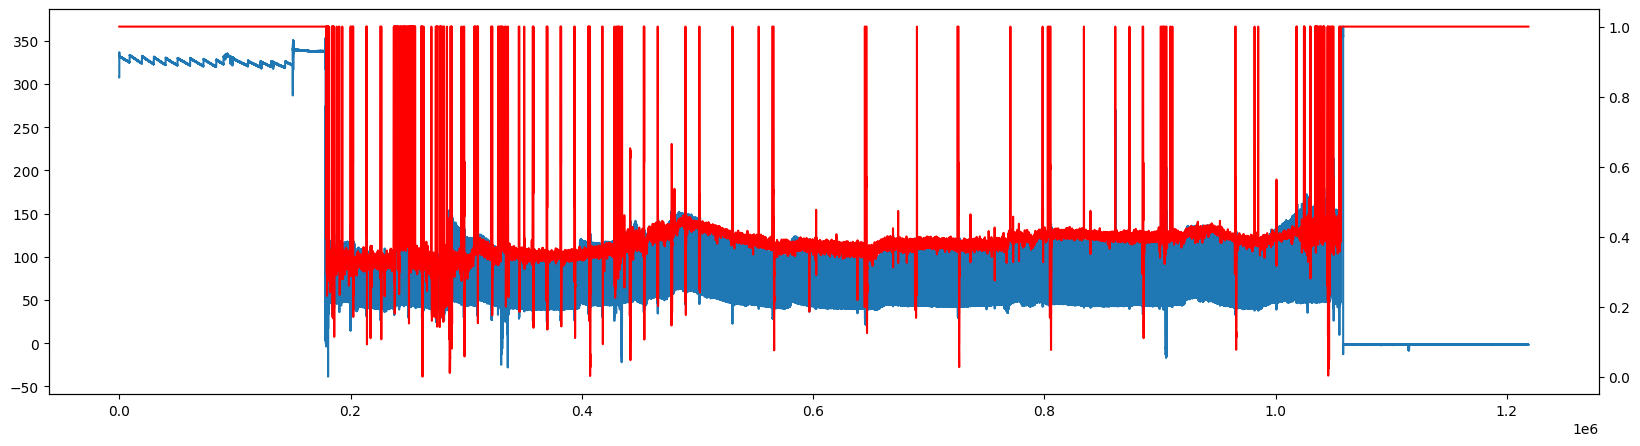

In [17]:
plt.figure(figsize=(20, 5))
plt.plot(sig)
axs = plt.gca().twinx()
axs.plot(sqi, color="r")
plt.show()